<a href="https://colab.research.google.com/github/chrispchen/ChenHypoxia/blob/main/Overrepresentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hypoxia induced, *tent5ba* dependent

In [ ]:
!pip install gseapy
import gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 8.7 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import gseapy as gp
from glob import glob

# simple plotting function
from gseapy import barplot, dotplot

In [ ]:
Hypoxia_Genes = pd.read_csv('/content/drive/MyDrive/Chris/All/BulkTent/Hypoxia_18hrs_WTVsNormoxia_6hpf_WTDGEGenesAll.csv')

In [ ]:
Hypoxia_Genes

,genes,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ABCD2,23.765118,-0.868225,0.395319,-2.196266,0.028073,0.072085
1,ACKR2,0.374447,2.107107,3.123855,0.674521,0.499980,NaN
2,ACOT12,147.510130,-0.127575,0.270468,-0.471682,0.637154,0.762689
3,ACSF3,38.978575,-1.217850,0.462193,-2.634941,0.008415,0.026220
4,ACVR1C,4.196594,2.105363,1.346083,1.564066,0.117802,0.227253
...,...,...,...,...,...,...,...
25981,zwilch,366.333578,-0.530354,0.188844,-2.808422,0.004978,0.016686
25982,zyg11,266.144112,0.655642,0.183945,3.564338,0.000365,0.001676
25983,zyx,2244.292273,0.542051,0.170076,3.187104,0.001437,0.005652
25984,zzef1,531.354550,-0.610710,0.223158,-2.736675,0.006206,0.020181


In [ ]:
tent42 = pd.read_csv('/content/drive/MyDrive/Chris/All/BulkTent/Hypoxia_18hrs_Tent5ba42VsHypoxia_18hrs_WTDGEGenesAll.csv')

In [ ]:
tent42

,genes,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ABCD2,15.707030,0.100224,0.410019,0.244438,8.068920e-01,8.973897e-01
1,ACKR2,0.620902,-0.179691,2.630057,-0.068322,9.455292e-01,NaN
2,ACOT12,150.576469,0.450808,0.184733,2.440320,1.467424e-02,5.296525e-02
3,ACSF3,18.411377,-0.424581,0.449205,-0.945184,3.445649e-01,5.387054e-01
4,ACVR1C,7.341310,0.470747,0.790817,0.595267,5.516650e-01,7.242116e-01
...,...,...,...,...,...,...,...
25981,zwilch,233.007143,-0.467014,0.134052,-3.483826,4.942999e-04,3.329740e-03
25982,zyg11,257.472813,-0.399791,0.159373,-2.508524,1.212366e-02,4.549237e-02
25983,zyx,1506.717401,-1.962341,0.122715,-15.990996,1.476525e-57,7.022255e-54
25984,zzef1,335.102990,-0.379601,0.150399,-2.523969,1.160382e-02,4.389264e-02


In [ ]:
# Select only the columns you want from each dataframe
df1 = Hypoxia_Genes[['genes', 'log2FoldChange', 'padj']].copy()
df2 = tent42[['genes', 'log2FoldChange', 'padj']].copy()

# Rename columns to add prefixes (except 'genes')
df1.columns = ['genes',
               'log2FoldChange_Hypoxia_18hrs_WT_Vs_Normoxia_6hpf_WT',
               'padj_Hypoxia_18hrs_WT_Vs_Normoxia_6hpf_WT']

df2.columns = ['genes',
               'log2FoldChange_Hypoxia_18hrs_Tent5ba42_Vs_Hypoxia_18hrs_WT',
               'padj_Hypoxia_18hrs_Tent5ba42_Vs_Hypoxia_18hrs_WT']

# Merge on 'genes'
merged_df = df1.merge(df2, on='genes', how='outer')

# Save to CSV
merged_df.to_csv('/content/drive/MyDrive/Chris/All/BulkTent/TentSpecific.csv', index=False)

# Display first few rows
merged_df.head()

,genes,log2FoldChange_Hypoxia_18hrs_WT_Vs_Normoxia_6hpf_WT,padj_Hypoxia_18hrs_WT_Vs_Normoxia_6hpf_WT,log2FoldChange_Hypoxia_18hrs_Tent5ba42_Vs_Hypoxia_18hrs_WT,padj_Hypoxia_18hrs_Tent5ba42_Vs_Hypoxia_18hrs_WT
0,ABCD2,-0.868225,0.072085,0.100224,0.897390
1,ACKR2,2.107107,NaN,-0.179691,NaN
2,ACOT12,-0.127575,0.762689,0.450808,0.052965
3,ACSF3,-1.217850,0.026220,-0.424581,0.538705
4,ACVR1C,2.105363,0.227253,0.470747,0.724212


In [ ]:
HypoxUp = Hypoxia_Genes[(Hypoxia_Genes['padj'] < 0.05) & (Hypoxia_Genes['log2FoldChange'] > 0.5)]['genes'].astype(str).tolist()

In [ ]:
HypoxUp

['ADAMTS7',
 'AL772146.2',
 'AL840638.1',
 'AL928650.4',
 'AL928835.1',
 'AL935174.2',
 'AL935198.1',
 'ANO7',
 'ANXA1',
 'ARHGEF17',
 'ATE1',
 'ATG14',
 'BX004981.1',
 'BX005309.1',
 'BX072576.2',
 'BX072577.1',
 'BX088596.1',
 'BX088707.3',
 'BX119902.3',
 'BX248497.1',
 'BX279523.1',
 'BX322555.3',
 'BX323555.2',
 'BX323590.1',
 'BX323839.1',
 'BX470259.3',
 'BX510649.1',
 'BX511311.2',
 'BX530407.6',
 'BX537263.2',
 'BX537263.3',
 'BX537342.1',
 'BX548247.1',
 'BX569789.1',
 'BX571794.2',
 'BX571794.3',
 'BX571942.1',
 'BX629344.1',
 'BX649398.3',
 'BX663503.1',
 'BX663503.3',
 'BX663611.1',
 'BX682234.1',
 'BX890539.1',
 'BX908386.3',
 'BX908731.1',
 'BX927082.1',
 'BX927184.1',
 'BX927327.1',
 'BX936305.1',
 'BX936456.1',
 'BX950855.1',
 'BX957278.1',
 'BX957346.1',
 'C14orf28',
 'CABZ01005379.1',
 'CABZ01007816.1',
 'CABZ01010098.1',
 'CABZ01011673.1',
 'CABZ01037174.1',
 'CABZ01039863.1',
 'CABZ01040021.1',
 'CABZ01045617.1',
 'CABZ01046954.1',
 'CABZ01048053.1',
 'CABZ01048392

In [ ]:
len(HypoxUp)

3857

In [ ]:
TentDown = tent42[(tent42['padj'] < 0.05) & (tent42['log2FoldChange'] < -0.5)]['genes'].astype(str).tolist()

In [ ]:
TentDown

['ADAMTS7',
 'AL590149.1',
 'AL928650.3',
 'AL928650.4',
 'AL928714.1',
 'AL954322.3',
 'ANXA1',
 'ARSB',
 'BX001026.1',
 'BX001030.1',
 'BX005321.1',
 'BX005329.2',
 'BX072577.1',
 'BX088707.3',
 'BX119909.1',
 'BX279523.1',
 'BX294434.1',
 'BX322665.1',
 'BX323880.1',
 'BX324006.3',
 'BX324132.1',
 'BX465228.1',
 'BX470259.3',
 'BX510992.1',
 'BX511013.1',
 'BX511034.1',
 'BX511034.5',
 'BX511034.7',
 'BX511111.1',
 'BX511265.3',
 'BX530407.6',
 'BX537110.1',
 'BX546499.2',
 'BX548073.3',
 'BX571712.3',
 'BX571794.2',
 'BX629344.1',
 'BX649300.1',
 'BX649556.2',
 'BX649622.2',
 'BX681417.2',
 'BX890539.1',
 'BX890558.1',
 'BX908756.2',
 'BX908757.2',
 'BX908757.3',
 'BX914205.3',
 'BX927336.1',
 'BX936320.1',
 'BX936431.1',
 'BX936433.1',
 'BX936433.2',
 'BX957326.1',
 'CABZ01033394.1',
 'CABZ01035279.1',
 'CABZ01035356.1',
 'CABZ01038521.1',
 'CABZ01038524.1',
 'CABZ01038697.1',
 'CABZ01043955.1',
 'CABZ01044099.1',
 'CABZ01044731.1',
 'CABZ01048392.1',
 'CABZ01048402.1',
 'CABZ0104

In [ ]:
TentSpecific = [value for value in HypoxUp if value in TentDown]

In [ ]:
TentSpecific

['ADAMTS7',
 'AL928650.4',
 'ANXA1',
 'BX072577.1',
 'BX088707.3',
 'BX279523.1',
 'BX470259.3',
 'BX530407.6',
 'BX571794.2',
 'BX629344.1',
 'BX890539.1',
 'CABZ01048392.1',
 'CABZ01048402.2',
 'CABZ01072810.1',
 'CABZ01079080.1',
 'CABZ01083943.1',
 'CABZ01090890.1',
 'CR318588.3',
 'CR354435.2',
 'CR735102.1',
 'CR762420.1',
 'CR762436.1',
 'CR762436.2',
 'CT573248.1',
 'CU457819.2',
 'CU459186.1',
 'CU655961.2',
 'CU681855.1',
 'FO681288.1',
 'FO834799.1',
 'FO834800.1',
 'FP236513.1',
 'FP236812.1',
 'FP236812.2',
 'FP325123.1',
 'GRB14',
 'LO018340.1',
 'LOC100007813',
 'LOC100334934',
 'LOC108179108',
 'LOC108190747',
 'LOC110437968',
 'LOC564610',
 'LOC570405',
 'MTERF1',
 'NUP85',
 'SFMBT1',
 'TENT5A',
 'TMEM19',
 'aatka',
 'abat',
 'acap3a',
 'acbd5a',
 'acsl3a',
 'acsl4a',
 'acta2',
 'actn3b',
 'adcy6b',
 'adcy7',
 'adgrg2a',
 'adrb2b',
 'agap1',
 'agrn',
 'ahr2',
 'ahsa1a',
 'ak9',
 'aldocb',
 'alkbh5',
 'amt',
 'angptl4',
 'ankrd28b',
 'ankrd37',
 'anks4b',
 'anxa2a',
 'a

In [ ]:
len(TentSpecific)

651

In [ ]:
enr_res = gseapy.enrichr(gene_list=TentSpecific, organism='Fish', gene_sets='WikiPathways_2018')


In [ ]:
go = enr_res.res2d
go

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Z-score,Combined Score,Genes
0,WikiPathways_2018,Glycolysis and Gluconeogenesis_WP1356,8/47,0.000124,0.007536,0.000355,0.021677,-2.000042,17.998214,gpia;aldocb;got2b;ldha;eno1a;gapdhs;pcxb;pgk1
1,WikiPathways_2018,PPAR Signaling Pathway_WP4020,6/56,0.009491,0.289466,0.015466,0.471709,-1.610609,7.501326,ubb;acsl3a;acsl4a;angptl4;scp2a;plin2
2,WikiPathways_2018,Apoptosis Modulation by HSP70_WP1392,2/15,0.083990,0.718624,0.107389,0.849043,-2.378386,5.891387,tnfrsf1a;casp6
3,WikiPathways_2018,Mitochondrial LC-Fatty Acid Beta-Oxidation_WP498,2/13,0.065091,0.718624,0.086480,0.849043,-2.088361,5.705354,acsl4a;scp2a
4,WikiPathways_2018,Oxidative Stress_WP1372,3/28,0.061577,0.718624,0.081413,0.849043,-2.034245,5.670395,hmox1a;gpx3;mao
...,...,...,...,...,...,...,...,...,...,...
56,WikiPathways_2018,G1 to S cell cycle control_WP445,2/57,0.557883,0.827559,0.590587,0.870823,0.759712,-0.443373,cdkn1a;ccng2
57,WikiPathways_2018,ERK1 - ERK2 MAPK cascade_WP402,3/126,0.782106,0.879116,0.813372,0.907781,1.838047,-0.451727,mapk8b;fgf13b;raf1a
58,WikiPathways_2018,T Cell Receptor Signaling Pathway_WP1345,3/84,0.518031,0.827559,0.558753,0.870823,0.699771,-0.460253,stat1a;card11;git2a
59,WikiPathways_2018,Transformation Growth Factor (TGF) beta Recept...,3/127,0.786598,0.879116,0.817551,0.907781,1.976754,-0.474496,foxo1a;cav1;cdkn1a


In [ ]:
go.to_csv('/content/drive/MyDrive/Chris/All/BulkTent/TentSpecific_wikipathways.csv')

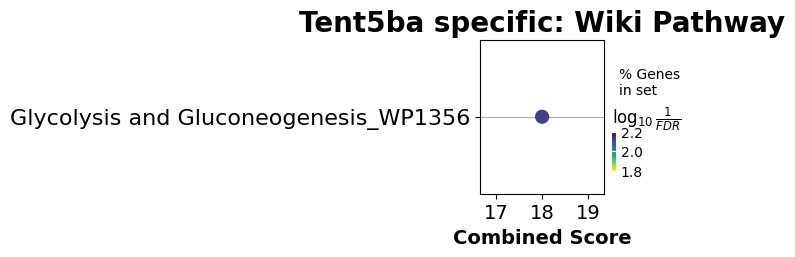

In [ ]:
ax = dotplot(enr_res.res2d, title='Tent5ba specific: Wiki Pathway',cmap='viridis_r', size=10, figsize=(2,2), dpi = 300)

In [ ]:
# KEGG

In [ ]:


enr_res = gseapy.enrichr(gene_list=TentSpecific, organism='Fish', gene_sets='KEGG_2019')
goterms = enr_res.res2d.loc[:, ['Term', 'Adjusted P-value', 'Genes']]
goterms = goterms.sort_values('Adjusted P-value')


In [ ]:
goterms

,Term,Adjusted P-value,Genes
14,PPAR signaling pathway,0.156298,sorbs1;ubb;acsl3a;acsl4a;angptl4;rxrgb;scp2a;p...
29,Glycolysis / Gluconeogenesis,0.209737,gpia;aldocb;ldha;eno1a;gapdhs;pgk1;bpgm;pgm1
9,Peroxisome,0.293035,acsl3a;pex5;acsl4a;crata;hmgcl;crot;scp2a;gstk1
1,SNARE interactions in vesicular transport,0.336817,gosr1;bet1l;vamp2;vamp5;bnip1b
20,Pentose phosphate pathway,0.404604,gpia;aldocb;h6pd;pgm1
...,...,...,...
82,Neuroactive ligand-receptor interaction,0.993150,drd1a;htr1ab;grin3a;lepr;chrnb2b;grid1a;adrb2b...
77,TGF-beta signaling pathway,0.993150,rps6kb1a
73,Ubiquitin mediated proteolysis,0.993150,ube2h
81,RNA transport,0.993150,nup85;eif4ebp3l


In [ ]:
# GO

In [ ]:


enr_res = gseapy.enrichr(gene_list=TentSpecific, organism='Fish', gene_sets='GO_Biological_Process_2018')
goterms = enr_res.res2d.loc[:, ['Term', 'Adjusted P-value', 'Genes']]
goterms = goterms.sort_values('Adjusted P-value')


In [ ]:
goterms

,Term,Adjusted P-value,Genes
36,negative regulation of transcription from RNA ...,0.093650,brms1;nfia;dnajb4;cica;sox17;mier1b;sox9b;foxo...
40,"negative regulation of transcription, DNA-temp...",0.147698,brms1;nfia;dnajb4;cica;sox17;zic2a;cipca;cipcb...
0,positive regulation of chondrocyte differentia...,0.362373,loxl2b;loxl2a;sox9b
1,positive regulation of cartilage development (...,0.424348,loxl2b;loxl2a;sox9b
7,chaperone mediated protein folding requiring c...,0.471949,dnajb4;zgc:122979;hspa5;hspe1
...,...,...,...
891,protein transport (GO:0015031),0.997505,arl4ab;ap3d1;scamp4
895,negative regulation of apoptotic process (GO:0...,0.997621,cln3;tyro3;snx7
885,negative regulation of programmed cell death (...,0.998845,tyro3;snx7
886,cellular protein localization (GO:0034613),0.998845,arl4ab;ap3d1


In [ ]:
# GO molec

In [ ]:


enr_res = gseapy.enrichr(gene_list=TentSpecific, organism='Fish', gene_sets='GO_Molecular_Function_2018')
goterms = enr_res.res2d.loc[:, ['Term', 'Adjusted P-value', 'Genes']]
goterms = goterms.sort_values('Adjusted P-value')


In [ ]:
goterms

,Term,Adjusted P-value,Genes
0,transcription cofactor binding (GO:0001221),0.673490,per1a;nr1d2a;rorab
1,insulin-like growth factor receptor binding (G...,0.673490,igf3;igf2b
2,beta-galactosidase activity (GO:0004565),0.673490,slc37a4b;glb1
3,"oxidoreductase activity, acting on the CH-NH2 ...",0.673490,loxl2b;loxl2a;mao
4,oxysterol binding (GO:0008142),0.673490,nr1d2a;rorab
...,...,...,...
259,protein homodimerization activity (GO:0042803),0.999887,cdh17
261,RNA polymerase II core promoter proximal regio...,0.999887,mespbb;znf1144;zbtb7b
263,core promoter proximal region sequence-specifi...,0.999887,mespbb;znf1144;zbtb7b
262,G-protein coupled receptor activity (GO:0004930),0.999887,parapinopsinb;htr1ab;f2rl2;gpr55a;opn1mw4


In [ ]:
# GO Cellular Component

In [ ]:


enr_res = gseapy.enrichr(gene_list=TentSpecific, organism='Fish', gene_sets='GO_Cellular_Component_2018')
goterms = enr_res.res2d.loc[:, ['Term', 'Adjusted P-value', 'Genes']]
goterms = goterms.sort_values('Adjusted P-value')


In [ ]:
goterms

,Term,Adjusted P-value,Genes
1,main axon (GO:0044304),0.048706,sptan1;sirt2;zgc:112001;nav1b
0,paranode region of axon (GO:0033270),0.059367,sptan1;sirt2;zgc:112001
2,axon initial segment (GO:0043194),0.528461,zgc:112001;nav1b
3,autophagosome membrane (GO:0000421),0.614611,tecpr1a;map1lc3cl;zgc:92606
4,Golgi cisterna (GO:0031985),0.872990,gosr1;yipf6
...,...,...,...
105,nucleus (GO:0005634),0.976313,stk35;znf385b;raver1;cipca;cipcb;pdcd4b;znf341...
107,cytosolic ribosome (GO:0022626),0.979675,rps27l
104,cytosolic part (GO:0044445),0.993924,rps27l
101,nuclear lumen (GO:0031981),0.995173,kpna5;relb;mier1b
